## The 2D Ising Model and Heat‑Bath Monte Carlo

### Author: Łukasz Grzegrzółka

The two‑dimensional Ising model is one of the most fundamental systems in statistical physics. It consists of spins $s_{i} = \pm 1 $ arranged on a square lattice, interacting only with their nearest neighbours. The Hamiltonian of the system is: 
$E = -J \sum_{\langle ij \rangle} s_i s_j - B \sum_i s_i $ ,

where $J$ is the interaction strength and $B$ is an external magnetic field. In this project we set $J = 1$ and $B = 0$, so the model describes a ferromagnet with no external bias.

At finite temperature, the system is assumed to be in contact with a thermal reservoir, meaning that the probability of occupying a configuration $X$ with energy $E(X)$ is given by the Boltzmann distribution
$ P(X) = \frac{1}{Z} e^{-\beta E(X)}, \qquad \beta = \frac{1}{T}$. 

Instead of enumerating all $2^{L^2}$ spin configurations, we generate representative states using the heat‑bath Monte Carlo algorithm. In each Monte Carlo step (MCS), a randomly chosen spin is updated according to the exact conditional probability of being $+1$ or $-1$, given the state of its neighbours. This produces a Markov chain whose stationary distribution is the canonical ensemble.

The observables of interest are:

- magnetization per spin: $ m = \frac{1}{L^2} \sum_i s_i $,

- magnetic susceptibility: $ \chi = \beta L^2 \left( \langle m^2 \rangle - \langle m \rangle^2 \right)$,

- specific heat: $ c = \frac{\beta^2}{L^2} \left( \langle E^2 \rangle - \langle E \rangle^2 \right)$.

These quantities reveal the thermodynamic behaviour of the system and allow us to study the ferromagnetic-paramagnetic phase transition at the Onsager critical temperature:

$ T_c = \frac{2}{\ln(1+\sqrt{2})} \approx 2.269$.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.special as spec
from tqdm import tqdm

J=1
B=0.0
N = 100         #w ilu temperaturach obliczamy podatność i magnetyzację
s_term = 5000      #ile kroków CS termalizacji wykonujemy
s_avg = 5000        #ile kroków CS z pomiarami wykonujemy

class Lattice:
    def __init__(self, L, T, B):                    #L- ile cząstek leży wzdłuż szerokości/długości siatki, T - temperatura układu, B - pole zewnętrzne
        self.L=L
        self.beta = 1/T
        self.B = B
        N = random.randint(0, 2**(L*L))
        self.s = np.array( list(np.binary_repr(N, width=L*L)), dtype=int )
        self.s = (2*self.s-1).reshape(L, L)


    def heat_bath(self):
        i = random.randint(0, self.L-1)
        j = random.randint(0, self.L-1)
        a = np.roll(self.s, 1, axis=0)
        a += np.roll(self.s, -1, axis=0)
        a += np.roll(self.s, 1, axis=1)
        a += np.roll(self.s, -1, axis=1)
        delta = 2 * a[i, j] + 2 * self.B

        r = random.uniform(0, 1)
        if r < 1/(1+np.exp(-1*self.beta*delta)):
             self.s[i, j]=1
        else:
             self.s[i, j]=-1


    def magnetization(self):
         return np.sum(self.s)/(self.L*self.L)
    

    def E(self, J=1):
        a = np.roll(self.s, 1, axis=0)
        a += np.roll(self.s, -1, axis=0)
        a += np.roll(self.s, 1, axis=1)
        a += np.roll(self.s, -1, axis=1)
        E = np.sum(J*a*(-1)*self.s)
        return E
    
    def evolution(self, intro_steps=s_term, proper_steps=s_avg):
        self.avg_mag = 0
        self.avg_pod = 0
        self.avg_mag0 = 0
        self.energy = []
        for _ in range(intro_steps*int(self.L/5)**2):
           self.heat_bath()
        for _ in range(proper_steps*int(self.L/5)**2):
            self.heat_bath()
            self.avg_mag += abs(self.magnetization())
            self.avg_mag0 += self.magnetization()
            self.avg_pod += self.magnetization()**2
            self.energy.append(self.E())
        self.avg_mag /= (proper_steps*int(self.L/5)**2)
        self.avg_mag0 /= (proper_steps*int(self.L/5)**2)
        self.avg_pod /= (proper_steps*int(self.L/5)**2)
        self.avg_pod = self.beta * self.L**2 * (self.avg_pod - self.avg_mag0**2)
        self.c = np.var(self.energy) * self.beta**2 / self.L**2


def model_c(T, J=J):
    kappa = 2*np.tanh( 2*J/T )/np.cosh( 2*J/T )
    kappa_2 = 2*np.tanh( 2*J/T )**2 - 1
    c = (2/np.pi) * (1/(T*np.tanh(2*J/T)))**2 * (2*spec.ellipk(kappa**2) - 2*spec.ellipe(kappa**2) - (1-kappa_2)*(np.pi/2 + kappa_2*spec.ellipk(kappa**2)) )
    return c

### Heat‑Bath Monte Carlo on a 5×5 Ising Lattice

In the first part of the project, we simulate the two‑dimensional Ising model on a small $ 5 \times 5$ square lattice using the heat‑bath Monte Carlo algorithm. Each spin $s_{i} = \pm 1 $ interacts with its four nearest neighbours, and the system evolves at a fixed temperature $T$ according to the Boltzmann distribution. Because the lattice is small, the total number of possible spin configurations is $2^{25}$, which is large but still small enough that exact thermodynamic averages are known from full enumeration.

The goal of this task is to verify that the Monte Carlo simulation correctly reproduces the equilibrium behaviour of the model. For each temperature, the algorithm performs:

- a thermalization stage (5000 Monte Carlo sweeps) to allow the system to reach equilibrium,

- a measurement stage (5000 sweeps) during which observables are accumulated.

The main observable is the average absolute magnetization:

$ \langle |m| \rangle = \left\langle \left| \frac{1}{L^2} \sum_i s_i \right| \right\rangle $

which measures the degree of spin alignment in the system. At low temperatures, the system is strongly ordered and the magnetization is close to one. As the temperature increases, thermal fluctuations disrupt the alignment and the magnetization decreases.

Because exact values of $ \langle |m| \rangle $ are known for a $5 \times 5$ lattice, this task provides a direct benchmark for the correctness of the implementation. The simulation results closely follow the exact values across all tested temperatures, demonstrating that the heat‑bath algorithm correctly samples the canonical ensemble and that the code faithfully reproduces the thermodynamic behaviour of the Ising model.

This part of the project serves as a validation step before moving on to larger lattices, where exact results are no longer available and Monte Carlo methods become essential.



In [ ]:
model_1 = Lattice(5, 1, B)
model_2 = Lattice(5, 2, B)
model_3 = Lattice(5, 3, B)
model_4 = Lattice(5, 4, B)
model_5 = Lattice(5, 5, B)

T = [1, 2, 3, 4, 5]
models = [model_1, model_2, model_3, model_4, model_5]

print(f"Modele 5x5, B = {model_1.B}")
for model in models:
     model.evolution()
     print(f"T = {(1/model.beta):.4} K,\tAverage magnetization = {model.avg_mag:.4},\tAverage susceptibility = {model.avg_pod:.4}")

print()

Modele 5x5, B = 0.0
T = 1.0 K,	Average magnetization = 0.9994,	Average susceptibility = 0.00127
T = 2.0 K,	Average magnetization = 0.9302,	Average susceptibility = 0.09412
T = 3.0 K,	Average magnetization = 0.5633,	Average susceptibility = 3.195
T = 4.0 K,	Average magnetization = 0.3509,	Average susceptibility = 1.142
T = 5.0 K,	Average magnetization = 0.2521,	Average susceptibility = 0.4772



### Magnetization and Susceptibility for L = 10 and L = 20

In the second part, the simulation is repeated for larger lattices (L = 10) and (L = 20), across a dense grid of temperatures: $ T \in [1, 5]$.

For each temperature:

1. 2000 MCS are used for thermalization,

2. 5000 MCS are used for measurements.

#### Magnetization vs. Temperature

For $T < T_c$, the system is ferromagnetic and exhibits spontaneous magnetization. For $T > T_c$, the system becomes paramagnetic and the magnetization vanishes.

The exact Onsager formula for the spontaneous magnetization in 2D is:

$ m(T) = \left[1 - \frac{1}{\sinh^4(2J/T)}\right]^{1/8}, \qquad T < T_c$.

The simulation results for $L = 10$ and $L = 20$ follow this curve increasingly well as $L$ grows, illustrating finite‑size scaling: larger systems approximate the thermodynamic limit more accurately.

#### Magnetic Susceptibility

The susceptibility is computed from fluctuations of magnetization:
$ \chi = \beta L^2 \left( \langle m^2 \rangle - \langle m \rangle^2 \right)$.

Unlike magnetization, there is no closed‑form analytical expression for $\chi(T)$ in 2D. The simulation shows a pronounced peak near $T_c$, which becomes sharper for larger $L$, reflecting the divergence of susceptibility in the thermodynamic limit.

This part of the project demonstrates:

- the emergence of a phase transition,

- the sharpening of thermodynamic singularities with system size,

- the agreement between Monte Carlo data and Onsager’s exact solution.

In [45]:
#zadanie 2

T2 = np.linspace(1, 5, N)
Ts = np.linspace(1, 2/np.log(1+np.sqrt(2))-0.00001, 1000)

def analytic_M(T):
    return ( 1 - 1/(np.sinh(2*J/T))**4 )**(1/8)

models_10 = [Lattice(10, i, B) for i in T2]
models_20 = [Lattice(10, i, B) for i in T2]

print(f"Modele 10x10, B = {models_10[0].B}, N = {N}, s_term = {s_term}, s_avg = {s_avg}")
for model in models_10:
    model.evolution()
    print(f"T = {(1/model.beta):.4} K,\tAverage magnetization = {model.avg_mag:.4},\tAverage susceptibility = {model.avg_pod:.4}")
print()

print(f"Modele 20x20, B = {models_20[0].B}, N = {N}, s_term = {s_term}, s_avg = {s_avg}")
for model in models_20:
    model.evolution()
    print(f"T = {1/model.beta} K,\tAverage magnetization = {model.avg_mag:.4},\tAverage susceptibility = {model.avg_pod:.4}")
print()




Modele 10x10, B = 0.0, N = 100, s_term = 5000, s_avg = 5000
T = 1.0 K,	Average magnetization = 0.9997,	Average susceptibility = 0.0005132
T = 1.04 K,	Average magnetization = 0.9984,	Average susceptibility = 0.003984
T = 1.081 K,	Average magnetization = 0.9988,	Average susceptibility = 0.002793
T = 1.121 K,	Average magnetization = 0.9972,	Average susceptibility = 0.006376
T = 1.162 K,	Average magnetization = 0.998,	Average susceptibility = 0.003732
T = 1.202 K,	Average magnetization = 0.9973,	Average susceptibility = 0.005059
T = 1.242 K,	Average magnetization = 0.9953,	Average susceptibility = 0.008652
T = 1.283 K,	Average magnetization = 0.998,	Average susceptibility = 0.003398
T = 1.323 K,	Average magnetization = 0.9957,	Average susceptibility = 0.007756
T = 1.364 K,	Average magnetization = 0.9933,	Average susceptibility = 0.01193
T = 1.404 K,	Average magnetization = 0.9897,	Average susceptibility = 0.02224
T = 1.444 K,	Average magnetization = 0.9885,	Average susceptibility = 0.02196

### Plot the results

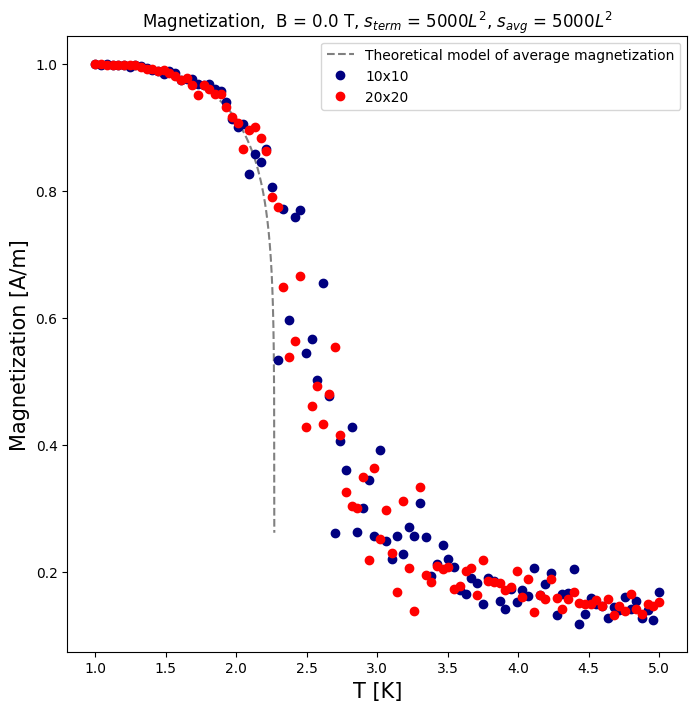

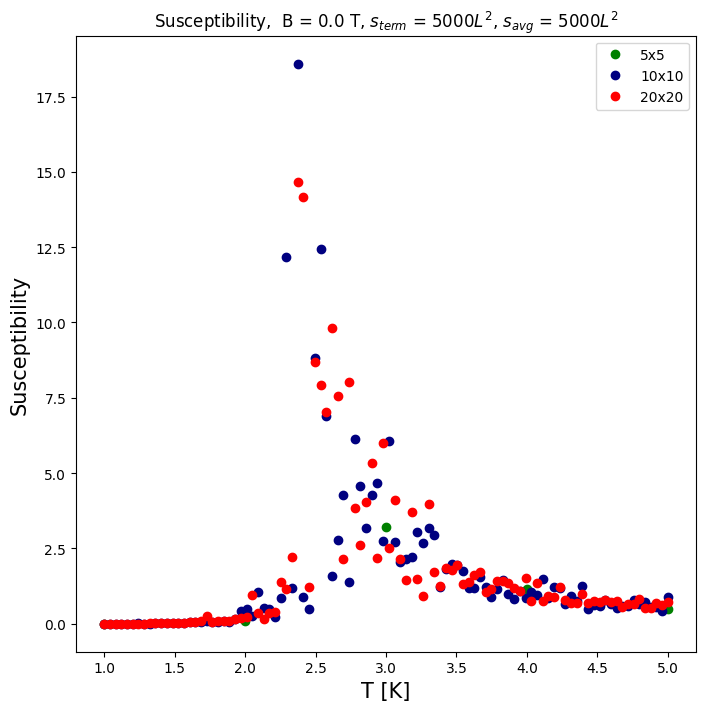

In [46]:
plt.figure(figsize=(8, 8))
plt.plot(Ts, analytic_M(Ts), "--", color="grey", label = "Theoretical model of average magnetization")
plt.plot(T2, [model.avg_mag for model in models_10], "o", color="navy", label="10x10")
plt.plot(T2, [model.avg_mag for model in models_20], "o", color="red", label="20x20")
plt.xlabel("T [K]", fontsize=15)
plt.ylabel("Magnetization [A/m]", fontsize=15)
plt.title(f"Magnetization,  B = "+f"{B} T"+", $s_{term}$" + f" = {s_term}"+r"$L^2$, $s_{avg}$ = "+ f"{s_avg}"+r"$L^2$")
plt.legend()
plt.show()

plt.figure(figsize=(8, 8))
plt.plot(T, [model.avg_pod for model in models], "o", color="green", label="5x5")
plt.plot(T2, [model.avg_pod for model in models_10], "o", color="navy", label="10x10")
plt.plot(T2, [model.avg_pod for model in models_20], "o", color="red", label="20x20")
plt.xlabel("T [K]", fontsize=15)
plt.ylabel("Susceptibility", fontsize=15)
plt.title(r"Susceptibility,  B = "+f"{B} T"+", $s_{term}$" + f" = {s_term}"+r"$L^2$, $s_{avg}$ = "+ f"{s_avg}"+r"$L^2$")
plt.legend()
plt.show()

### Specific Heat for a 50×50 Lattice

In the final part, the specific heat is computed for a larger lattice $L = 50$ over a finely sampled temperature range. The specific heat is defined as: 
$ c = \frac{\beta^2}{L^2} \left( \langle E^2 \rangle - \langle E \rangle^2 \right)$.

The exact expression for the specific heat of the 2D Ising model is known and involves complete elliptic integrals:

$ c(T) = \frac{2}{\pi} \left(\frac{1}{T \tanh(2J/T)}\right)^2 \left [ 2K(k^2) - 2E(k^2) - (1-k')\left(\frac{\pi}{2} + k' K(k^2)\right) \right ] $, 

where:

$ k = \frac{2 \tanh(2J/T)}{\cosh(2J/T)}, \qquad k' = 2\tanh^2(2J/T) - 1$,

and $K$, $E$ are complete elliptic integrals of the first and second kind.

The simulation reproduces the characteristic logarithmic divergence of the specific heat at the critical temperature TT_c$ a hallmark of the 2D Ising universality class.

This part demonstrates:

- the role of energy fluctuations in determining heat capacity,

- the critical behaviour of the Ising model,

- the agreement between Monte Carlo data and Onsager’s exact solution.

In [48]:
N=200
T1 = np.linspace(1., 1.9, int(N/10))
T2 = np.linspace(2., 3.5, int(2*N/3))
T3 = np.linspace(3.6, 5., N - int(N/10)- int(2*N/3)) 
T = np.concatenate((T1, T2, T3), axis=0)
T_an = np.linspace(1, 5, 1000)
L=10
models_50 = [Lattice(L, i, B) for i in T]


print(f"Modele {L}x{L}, B = {B}, N = {N}")
for model in models_50:
    model.evolution()
    print(f"T = {1/model.beta:.4} K,\tAverage heat capacity: {model.c:.4}")

print()

Modele 10x10, B = 0.0, N = 200
T = 1.0 K,	Average heat capacity: 0.06434
T = 1.047 K,	Average heat capacity: 0.0364
T = 1.095 K,	Average heat capacity: 0.1692
T = 1.142 K,	Average heat capacity: 0.2183
T = 1.189 K,	Average heat capacity: 0.3141
T = 1.237 K,	Average heat capacity: 0.2907
T = 1.284 K,	Average heat capacity: 0.3706
T = 1.332 K,	Average heat capacity: 0.26
T = 1.379 K,	Average heat capacity: 0.3862
T = 1.426 K,	Average heat capacity: 0.4622
T = 1.474 K,	Average heat capacity: 0.8031
T = 1.521 K,	Average heat capacity: 0.9299
T = 1.568 K,	Average heat capacity: 0.9823
T = 1.616 K,	Average heat capacity: 1.051
T = 1.663 K,	Average heat capacity: 0.8467
T = 1.711 K,	Average heat capacity: 1.901
T = 1.758 K,	Average heat capacity: 1.103
T = 1.805 K,	Average heat capacity: 1.218
T = 1.853 K,	Average heat capacity: 1.52
T = 1.9 K,	Average heat capacity: 2.035
T = 2.0 K,	Average heat capacity: 1.791
T = 2.011 K,	Average heat capacity: 2.833
T = 2.023 K,	Average heat capacity: 2.3

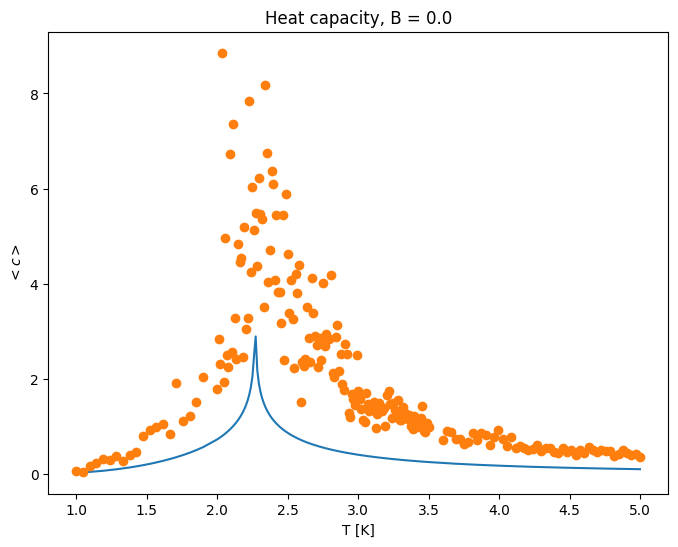

In [49]:
plt.figure(figsize=(8, 6))
plt.plot(T, model_c(T))
plt.plot(T, [model.c for model in models_50], "o", label="50x50")
plt.xlabel("T [K]")
plt.ylabel("$<c>$")
plt.title(f"Heat capacity, B = {B}")
plt.show()